# Small-Cap Network Analysis — El Sociograma del Mercado

**Analogía conceptual:** El mercado como un aula. Cada ticker es un alumno. Las categorías de Finviz (Top Gainers, Unusual Volume, New High…) son las "asignaturas" en las que aparece cada día. El objetivo: predecir qué alumnos van a "aprobar" (subida significativa) usando únicamente su comportamiento en el grupo, sin datos fundamentales.

**Marco teórico aplicado:**
- Análisis de redes de correlación (Mantegna 1999)
- Sociometría: co-aparición en categorías como proxy de similitud
- Análisis longitudinal: evolución de la posición del ticker en la red
- Cadenas de Markov: transiciones entre categorías
- Modelo predictivo con features de red

**Fuente de datos:** `finviz_snapshots.db` — 22 sesiones de trading (24 Mar – 24 Abr 2026), 968 tickers únicos, 15 categorías.

---

**Secciones:**
1. Carga y limpieza de datos
2. Universo y distribución de categorías
3. La red de co-aparición (sociograma)
4. Métricas de centralidad por ticker
5. Clusters de comportamiento (comunidades)
6. Trayectorias longitudinales (evolución temporal)
7. Matriz de transición Markov entre categorías
8. Señal predictiva: categoría hoy → retorno mañana
9. Conclusiones e hipótesis de trabajo

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Intentamos cargar networkx (si no está instalado, algunas secciones se saltarán)
try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    HAS_NX = False
    print('networkx no instalado. Instalar con: pip install networkx')
    print('Las secciones de grafo quedarán deshabilitadas.')

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import classification_report, roc_auc_score
    from sklearn.model_selection import TimeSeriesSplit
    HAS_SK = True
except ImportError:
    HAS_SK = False
    print('scikit-learn no instalado. Instalar con: pip install scikit-learn')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

DB_PATH = '/Users/carlos/Library/Application Support/finviz-dashboard/finviz_snapshots.db'
print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga y limpieza de datos

In [2]:
conn = sqlite3.connect(DB_PATH)

raw = pd.read_sql('SELECT * FROM snapshots', conn)
conn.close()

# Parsear timestamp
raw['ts'] = pd.to_datetime(raw['timestamp'], utc=True)
raw['date'] = raw['ts'].dt.tz_convert('America/New_York').dt.date
raw['date'] = pd.to_datetime(raw['date'])

# Parsear change_pct: algunos registros tienen '-' en lugar de número → tratamos como 0
raw['change_pct_num'] = pd.to_numeric(
    raw['change_pct'].str.replace('%', '', regex=False).replace('-', '0'),
    errors='coerce'
).fillna(0)

def parse_volume(v):
    if pd.isna(v) or v == '0':
        return np.nan
    v = str(v).replace(',', '')
    if 'K' in v:
        return float(v.replace('K','')) * 1_000
    if 'M' in v:
        return float(v.replace('M','')) * 1_000_000
    try:
        return float(v)
    except:
        return np.nan

raw['volume_num'] = raw['volume'].apply(parse_volume)
raw['price_num'] = pd.to_numeric(raw['price'], errors='coerce')

# Deduplicar: si el mismo ticker aparece en la misma categoría el mismo día más de una vez,
# nos quedamos con la fila con datos (change_pct != 0 si existe, si no la primera)
raw_sorted = raw.sort_values(['date','ticker','category','change_pct_num'], ascending=[True,True,True,False])
df = raw_sorted.drop_duplicates(subset=['date','ticker','category'], keep='first').copy()

print(f'Filas brutas: {len(raw):,}  →  tras deduplicar: {len(df):,}')
print(f'Días de trading: {df["date"].nunique()}')
print(f'Tickers únicos: {df["ticker"].nunique()}')
print(f'Categorías: {sorted(df["category"].unique())}')
print(f'Rango de fechas: {df["date"].min().date()} → {df["date"].max().date()}')

Filas brutas: 41,078  →  tras deduplicar: 2,641
Días de trading: 22
Tickers únicos: 968
Categorías: ['Downgrades', 'Earnings After', 'Earnings Before', 'Insider Buying', 'Insider Selling', 'Most Active', 'Most Volatile', 'New High', 'New Low', 'Overbought', 'Oversold', 'Top Gainers', 'Top Losers', 'Unusual Volume', 'Upgrades']
Rango de fechas: 2026-03-24 → 2026-04-24


## 2. Universo y distribución de categorías

Antes de construir la red, necesitamos entender la distribución del universo.

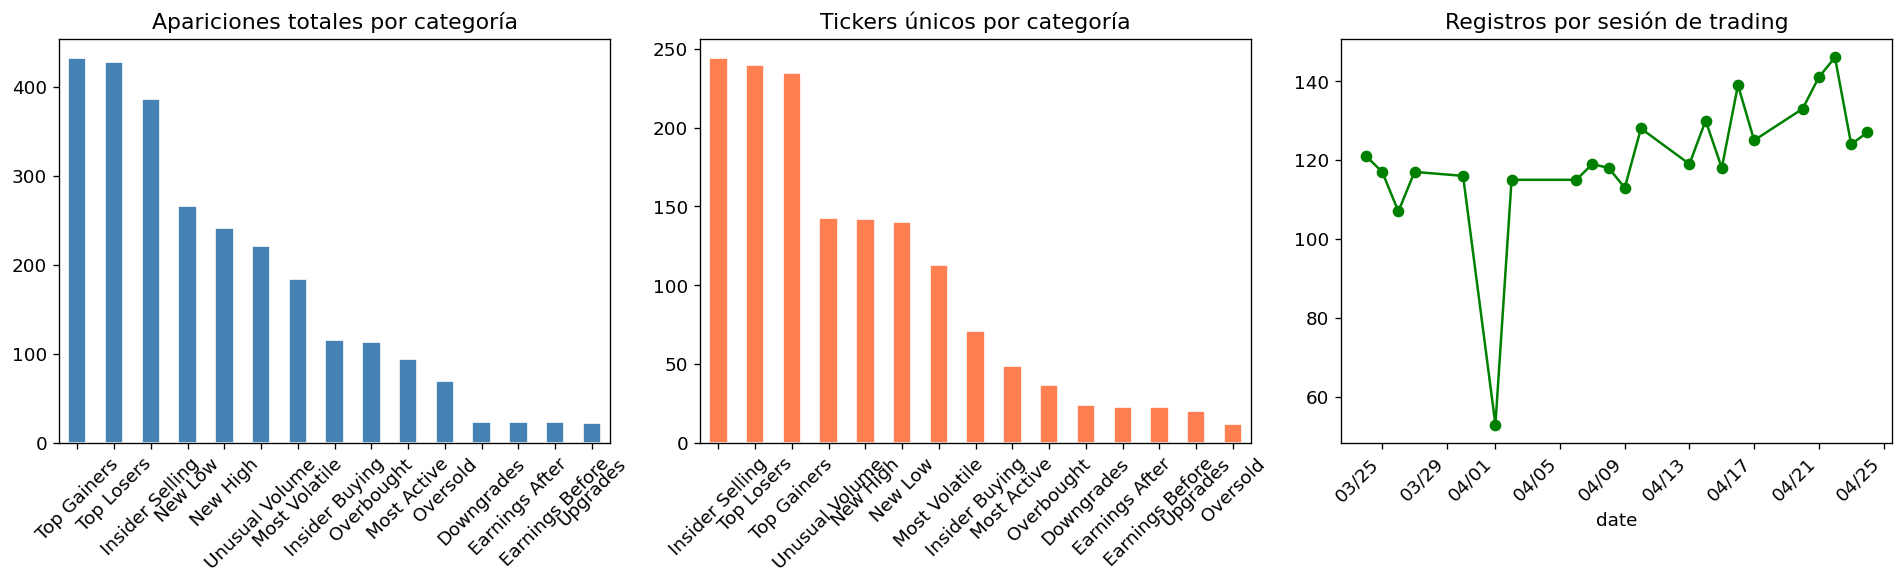


Distribución de categorías por ticker/día:
category
1    1578
2     268
3     122
4      29
5       9

Tickers que aparecen en 3+ categorías el mismo día: 160


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Apariciones por categoría (total) ---
cat_counts = df.groupby('category').size().sort_values(ascending=False)
cat_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Apariciones totales por categoría')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# --- Panel 2: Tickers únicos por categoría ---
cat_tickers = df.groupby('category')['ticker'].nunique().sort_values(ascending=False)
cat_tickers.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Tickers únicos por categoría')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# --- Panel 3: Snapshots por día ---
daily_rows = df.groupby('date').size()
daily_rows.plot(ax=axes[2], marker='o', color='green')
axes[2].set_title('Registros por sesión de trading')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- Resumen de presencia múltiple ---
presence = df.groupby(['ticker','date'])['category'].apply(list)
presence_count = presence.apply(len)
print(f'\nDistribución de categorías por ticker/día:')
print(presence_count.value_counts().sort_index().to_string())
print(f'\nTickers que aparecen en 3+ categorías el mismo día: {(presence_count>=3).sum()}')

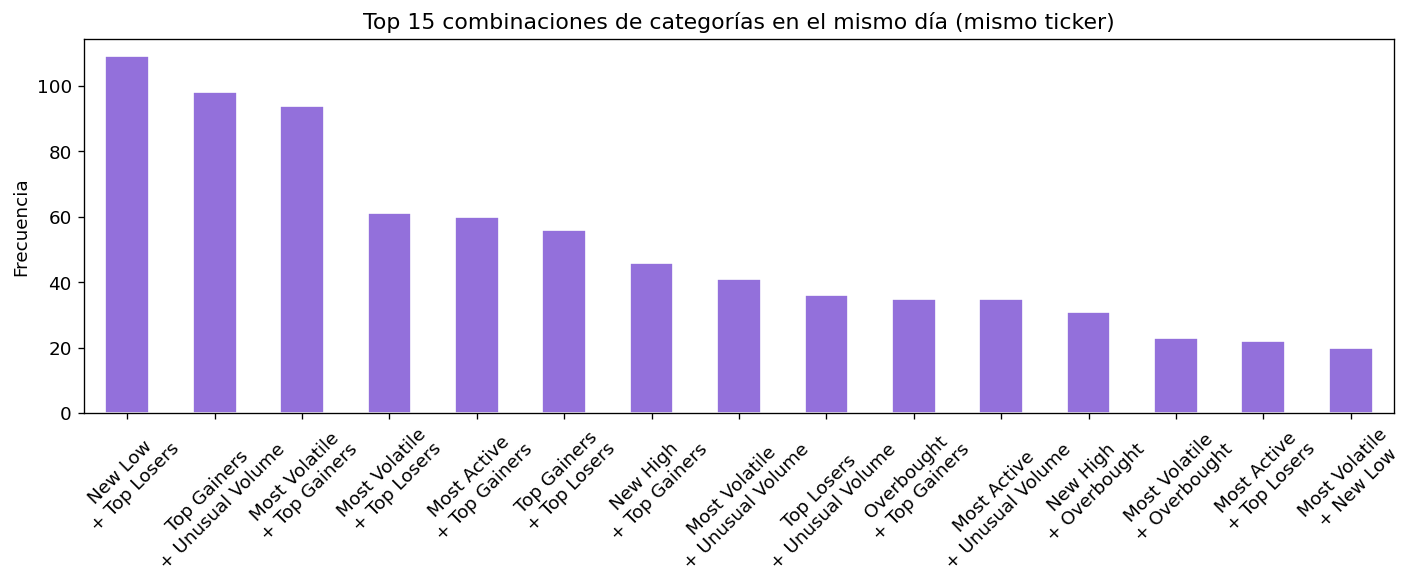


Interpretación: Las combinaciones más frecuentes indican qué señales tienden a aparecer juntas.
Ej: Top Gainers + Unusual Volume = movimiento con respaldo de volumen.


In [4]:
# ¿Qué combinaciones de categorías son más frecuentes el mismo día?
from itertools import combinations

combo_counts = defaultdict(int)
for (ticker, date), cats in presence.items():
    if len(cats) >= 2:
        for a, b in combinations(sorted(cats), 2):
            combo_counts[(a, b)] += 1

combos = pd.Series(combo_counts).sort_values(ascending=False).head(15)
combos.index = [f'{a}\n+ {b}' for a,b in combos.index]

fig, ax = plt.subplots(figsize=(12, 5))
combos.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Top 15 combinaciones de categorías en el mismo día (mismo ticker)')
ax.set_ylabel('Frecuencia')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\nInterpretación: Las combinaciones más frecuentes indican qué señales tienden a aparecer juntas.')
print('Ej: Top Gainers + Unusual Volume = movimiento con respaldo de volumen.')

## 3. La red de co-aparición (El Sociograma)

**Concepto:** Dos tickers son "compañeros de clase" si aparecen en las mismas categorías el mismo día. La frecuencia de co-aparición es la fuerza del lazo.

Construimos la red para cada día y luego la red agregada del período completo.

**Referencia:** Mantegna (1999) — usó correlaciones entre retornos para construir jerarquías; aquí usamos co-aparición en categorías, que captura similitud de comportamiento sin necesitar datos de precio continuos.

Tickers con >=3 apariciones: 279
Forma de la matriz ticker×categoría: (279, 15)


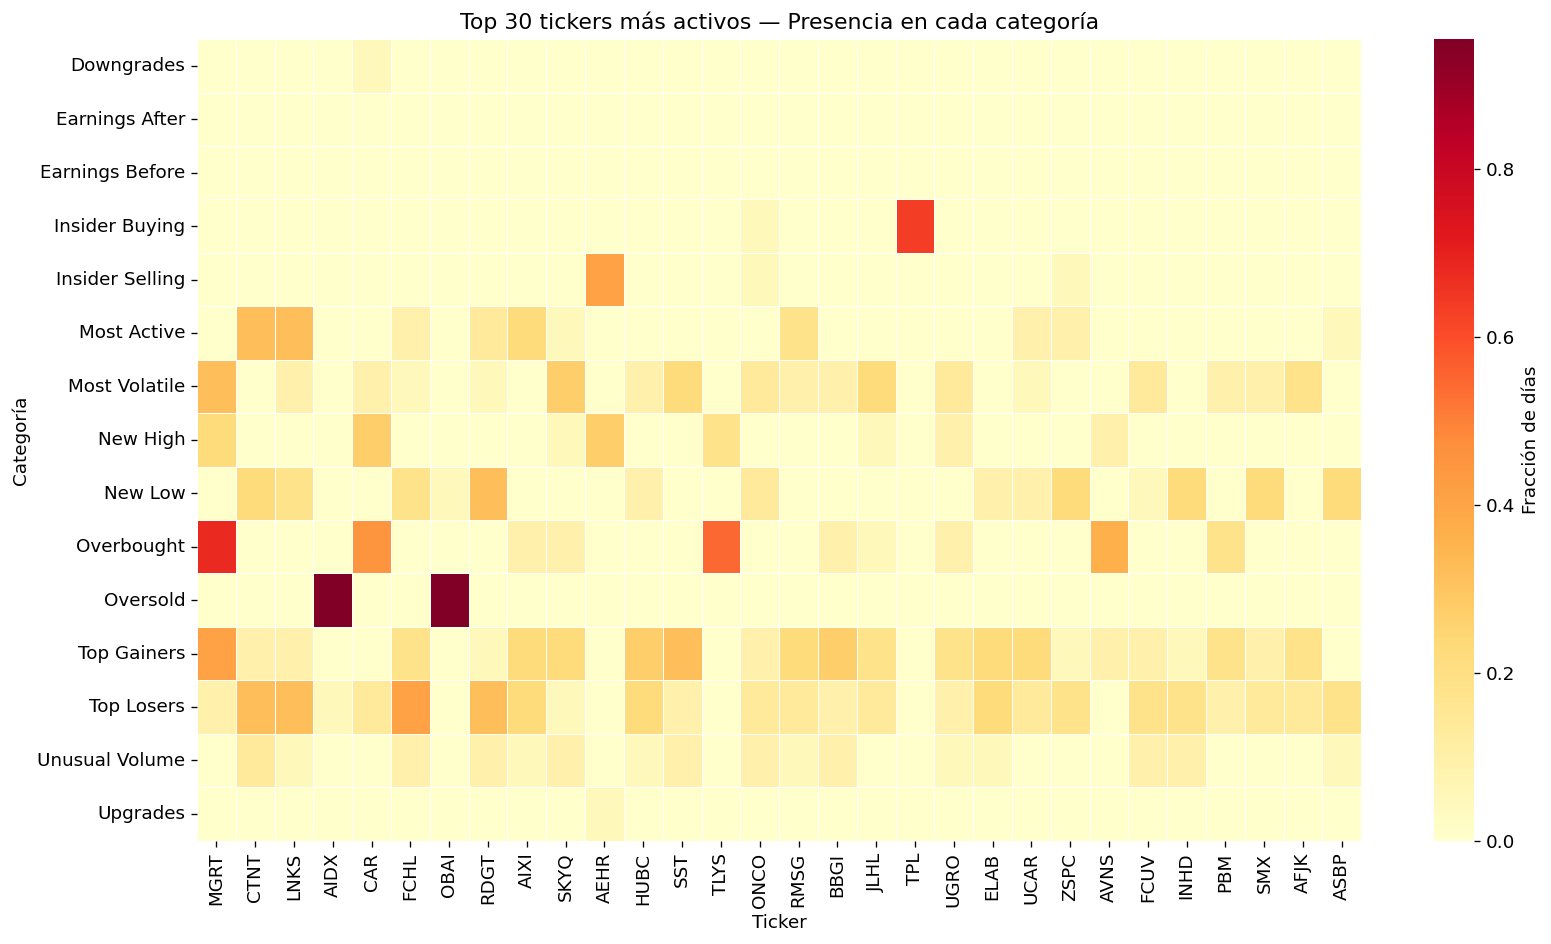

In [5]:
# ─── Matriz de co-aparición por categoría ───
# Enfoque: usamos las categorías como un espacio de características binarias
# y calculamos similitud de Jaccard entre tickers.

# Crear matriz binaria: ticker × categoría (1 si apareció alguna vez)
ALL_CATS = sorted(df['category'].unique())

# Pivotamos: para cada ticker, qué fracción de días apareció en cada categoría
n_days = df['date'].nunique()

ticker_cat = df.groupby(['ticker','category']).size().unstack(fill_value=0)
ticker_cat = ticker_cat.reindex(columns=ALL_CATS, fill_value=0)

# Filtrar tickers con al menos 3 apariciones totales (ruido)
ticker_total = ticker_cat.sum(axis=1)
ticker_cat_filt = ticker_cat[ticker_total >= 3].copy()

print(f'Tickers con >=3 apariciones: {len(ticker_cat_filt)}')
print(f'Forma de la matriz ticker×categoría: {ticker_cat_filt.shape}')

# Frecuencia relativa (qué % de días aparece en cada categoría)
ticker_freq = ticker_cat_filt / n_days

# Mapa de calor: categorías más frecuentes por ticker (top 30 tickers más activos)
top30 = ticker_total.nlargest(30).index
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(ticker_freq.loc[top30].T, cmap='YlOrRd', ax=ax, 
            linewidths=0.3, cbar_kws={'label': 'Fracción de días'})
ax.set_title('Top 30 tickers más activos — Presencia en cada categoría')
ax.set_xlabel('Ticker')
ax.set_ylabel('Categoría')
plt.tight_layout()
plt.show()

In [6]:
if not HAS_NX:
    print('networkx no disponible. Instalar con: pip install networkx')
else:
    from sklearn.metrics.pairwise import cosine_similarity
    
    # Calculamos similitud de coseno entre todos los pares de tickers
    # (espacio = vector de frecuencias en categorías)
    sim_matrix = cosine_similarity(ticker_freq.values)
    sim_df = pd.DataFrame(sim_matrix, index=ticker_freq.index, columns=ticker_freq.index)
    
    # Construir grafo: arista si similitud > umbral
    # Umbral elegido para mantener la red legible (~top 5% de pares)
    THRESHOLD = 0.7
    
    G = nx.Graph()
    for t in sim_df.index:
        G.add_node(t)
    
    edges_added = 0
    for i, t1 in enumerate(sim_df.index):
        for t2 in sim_df.index[i+1:]:
            w = sim_df.loc[t1, t2]
            if w >= THRESHOLD:
                G.add_edge(t1, t2, weight=w)
                edges_added += 1
    
    print(f'Grafo: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas (umbral similitud={THRESHOLD})')
    print(f'Densidad de red: {nx.density(G):.4f}')
    
    # Filtrar solo la componente gigante para visualizar
    largest_cc = max(nx.connected_components(G), key=len)
    G_main = G.subgraph(largest_cc).copy()
    print(f'Componente principal: {G_main.number_of_nodes()} nodos')

Grafo: 279 nodos, 5702 aristas (umbral similitud=0.7)
Densidad de red: 0.1470
Componente principal: 277 nodos


Comunidades detectadas: 5
  Comunidad 1 (138 tickers): ['AFJK', 'AGAE', 'AGPU', 'AIXI', 'AKAN', 'ANL', 'ANNA', 'APA', 'APLS', 'ARAI']...
  Comunidad 2 (84 tickers): ['ACHV', 'ADTX', 'AEHL', 'AIIO', 'AKTX', 'ALLO', 'ALP', 'AMST', 'ANGX', 'ARTL']...
  Comunidad 3 (38 tickers): ['ABNB', 'AEHR', 'AFL', 'AFYA', 'AGX', 'ARM', 'CACC', 'COCO', 'CRCL', 'DNA']...
  Comunidad 4 (11 tickers): ['AIRS', 'BMI', 'BZUN', 'KLTR', 'KYN', 'LGHL', 'MXF', 'NMR', 'RCG', 'TOI']...
  Comunidad 5 (6 tickers): ['AIDX', 'AMS', 'LGCB', 'LSTA', 'OBAI', 'TDTH']


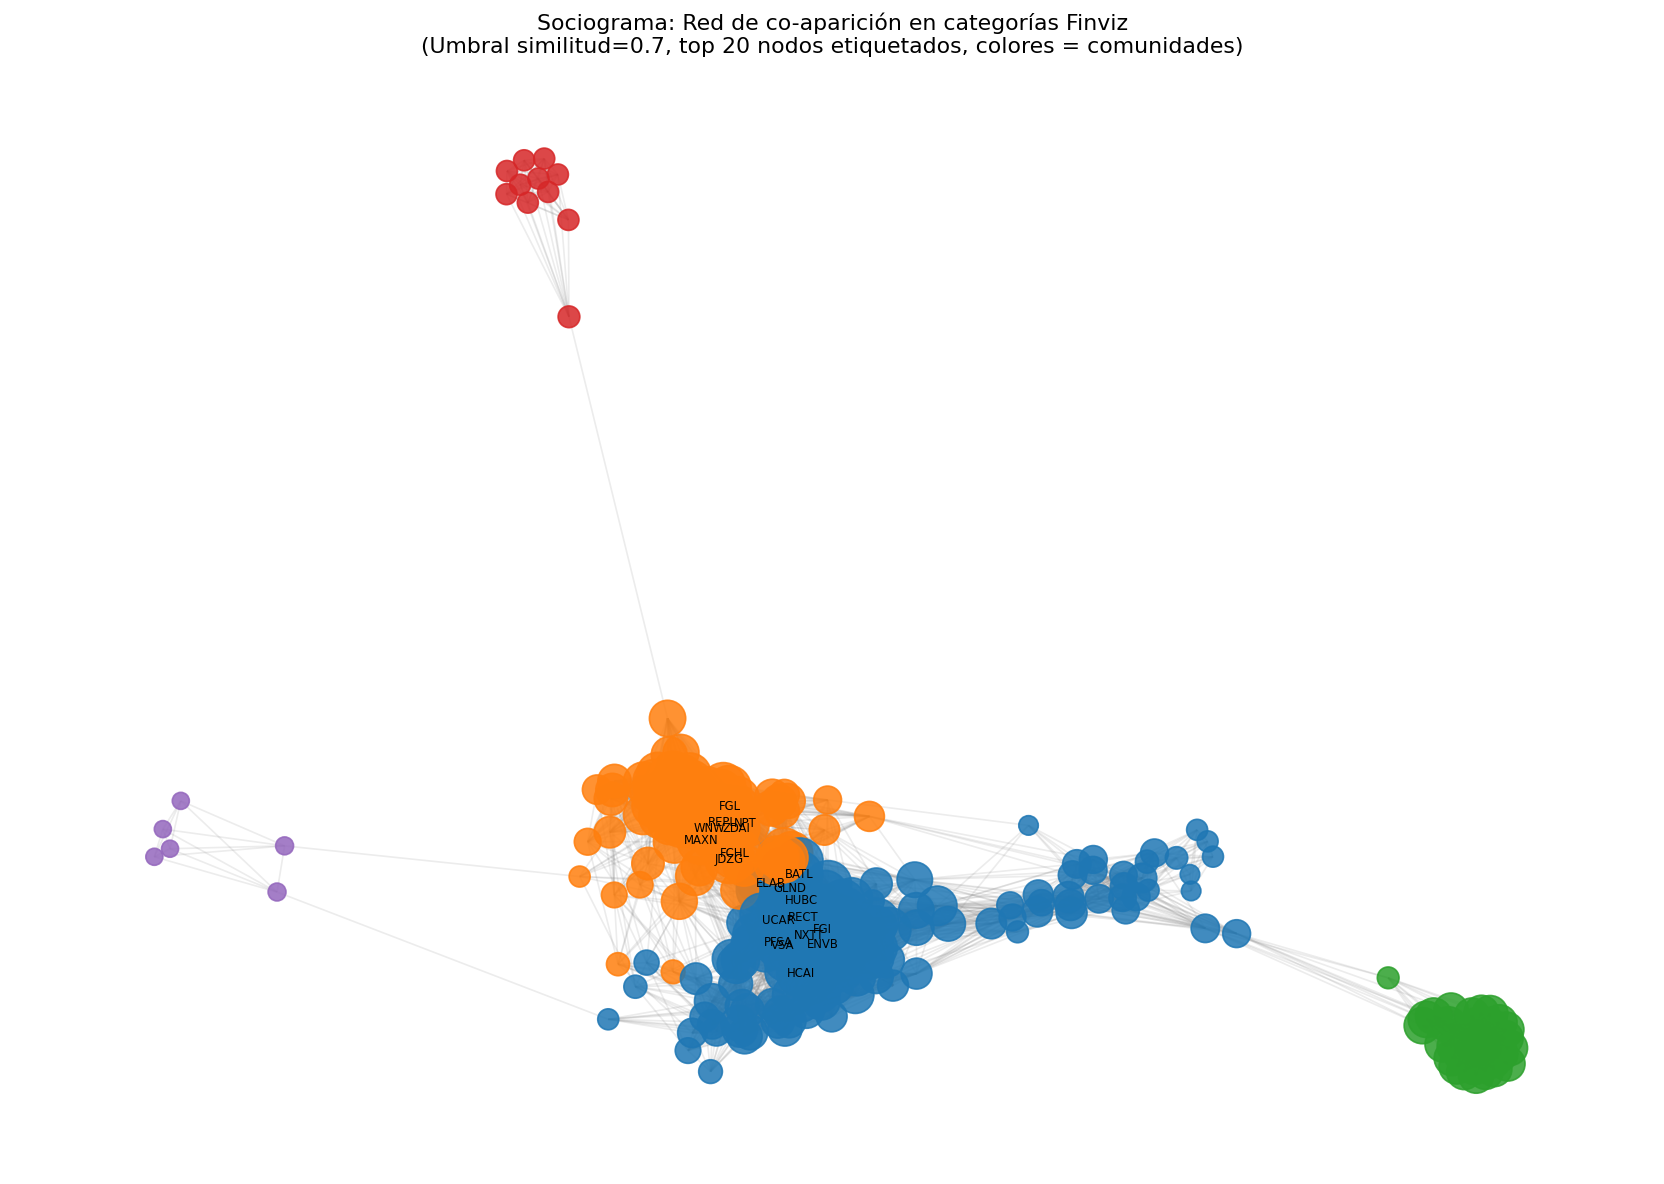

In [7]:
if not HAS_NX:
    print('networkx no disponible.')
else:
    # Visualización del grafo (componente principal)
    # Usamos spring layout para que los clusters queden separados
    
    # Detectar comunidades con el algoritmo de Louvain o greedy modularity
    communities = list(nx.community.greedy_modularity_communities(G_main))
    community_map = {}
    for i, comm in enumerate(communities):
        for node in comm:
            community_map[node] = i
    
    print(f'Comunidades detectadas: {len(communities)}')
    for i, comm in enumerate(communities):
        print(f'  Comunidad {i+1} ({len(comm)} tickers): {sorted(comm)[:10]}{"..." if len(comm)>10 else ""}')
    
    # Centralidad de grado
    degree_cent = nx.degree_centrality(G_main)
    betweenness_cent = nx.betweenness_centrality(G_main, weight='weight')
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 10))
    
    pos = nx.spring_layout(G_main, seed=42, k=2/np.sqrt(G_main.number_of_nodes()))
    
    colors = plt.cm.tab10(np.array([community_map.get(n,0) for n in G_main.nodes()]))
    sizes = [3000 * degree_cent[n] + 50 for n in G_main.nodes()]
    
    nx.draw_networkx_edges(G_main, pos, alpha=0.15, edge_color='gray', ax=ax)
    nx.draw_networkx_nodes(G_main, pos, node_color=colors, node_size=sizes, ax=ax, alpha=0.85)
    
    # Etiquetar solo los nodos más centrales
    top_nodes = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:20]
    labels = {n: n for n, _ in top_nodes}
    nx.draw_networkx_labels(G_main, pos, labels=labels, font_size=7, ax=ax)
    
    ax.set_title(f'Sociograma: Red de co-aparición en categorías Finviz\n(Umbral similitud={THRESHOLD}, top 20 nodos etiquetados, colores = comunidades)')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## 4. Métricas de centralidad por ticker

**Interpretación de la analogía:**
- **Centralidad de grado** = ticker popular: aparece en muchas categorías y junto a muchos otros tickers
- **Betweenness** = ticker "puente": conecta grupos distintos (ej: aparece en Unusual Volume y también en New High)
- **Eigenvector** = ticker conectado a otros tickers importantes (influencia de segundo orden)

**Hipótesis de trading:** Los tickers con alta centralidad de eigenvector tienen mayor exposición sistemática al régimen de mercado. En mercados alcistas, tienden a liderar; en bajistas, caen más.

Top 20 tickers por centralidad de grado (más "populares" en la red):
      degree  betweenness  eigenvector  days_active  total_appearances
HUBC  0.3043       0.0216       0.1111           11                 16
FCHL  0.3043       0.0067       0.1311            9                 22
RECT  0.3007       0.0199       0.1024            4                 10
NXTT  0.2971       0.0049       0.0969            4                  9
VSA   0.2862       0.0129       0.0848            4                  8
PFSA  0.2862       0.0129       0.0848            3                  8
UCAR  0.2826       0.0611       0.0909           10                 13
FGI   0.2790       0.0038       0.0948            7                  9
JDZG  0.2754       0.0058       0.1188            4                  5
REPL  0.2717       0.0025       0.1275            4                  6
ENVB  0.2681       0.0014       0.0886            6                 11
HCAI  0.2645       0.0049       0.0683            5                  8
ELAB  0.

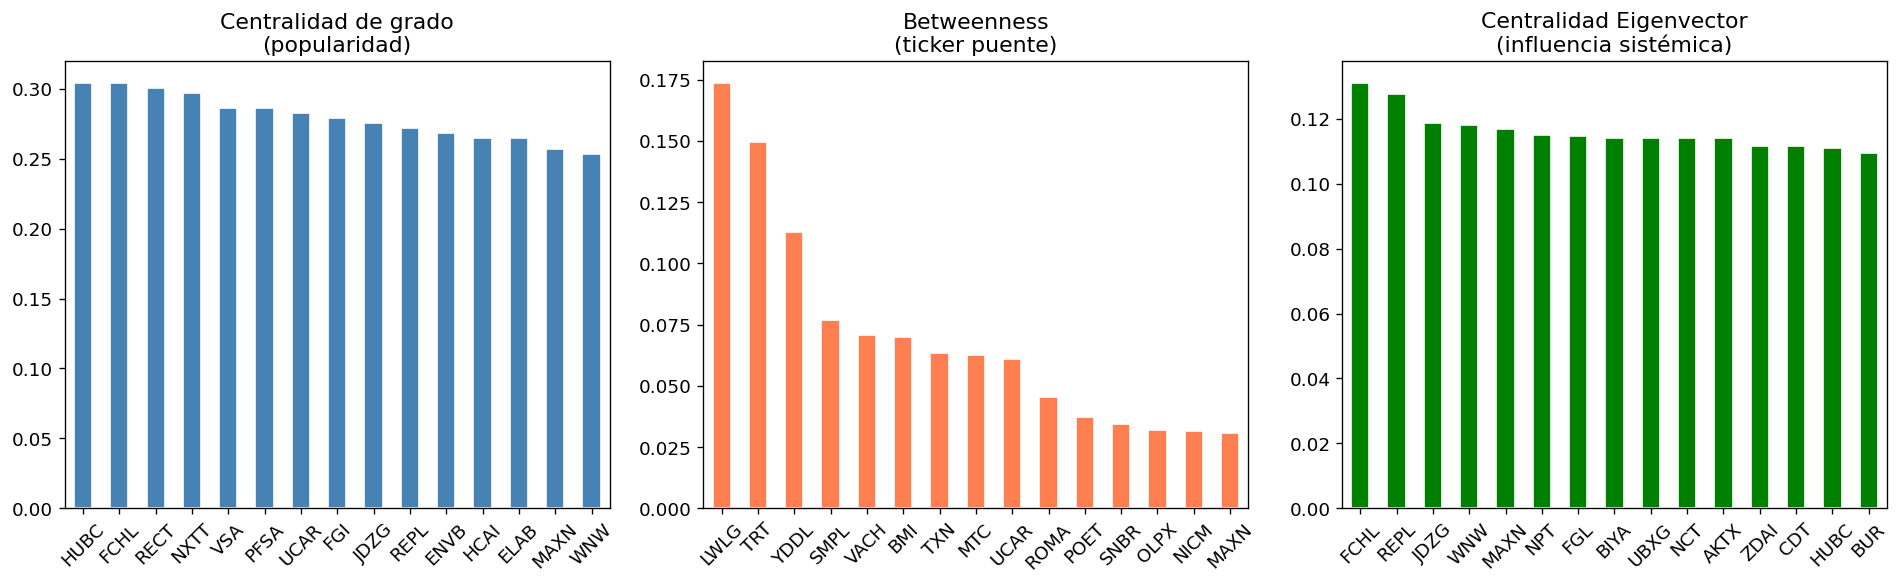

In [8]:
if not HAS_NX:
    print('networkx no disponible.')
else:
    # Calcular múltiples métricas de centralidad
    degree_c = pd.Series(nx.degree_centrality(G_main), name='degree')
    between_c = pd.Series(nx.betweenness_centrality(G_main, weight='weight'), name='betweenness')
    
    try:
        eigen_c = pd.Series(nx.eigenvector_centrality(G_main, max_iter=500, weight='weight'), name='eigenvector')
    except:
        eigen_c = pd.Series(0, index=degree_c.index, name='eigenvector')
    
    centrality_df = pd.concat([degree_c, between_c, eigen_c], axis=1).sort_values('degree', ascending=False)
    
    # Añadir cuántos días apareció el ticker
    days_active = df.groupby('ticker')['date'].nunique()
    centrality_df['days_active'] = days_active
    centrality_df['total_appearances'] = ticker_total
    
    print('Top 20 tickers por centralidad de grado (más "populares" en la red):')
    print(centrality_df.head(20).round(4).to_string())
    
    # Visualización
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, col, color, title in zip(axes,
        ['degree', 'betweenness', 'eigenvector'],
        ['steelblue', 'coral', 'green'],
        ['Centralidad de grado\n(popularidad)', 'Betweenness\n(ticker puente)', 'Centralidad Eigenvector\n(influencia sistémica)']):
        
        top15 = centrality_df[col].nlargest(15)
        top15.plot(kind='bar', ax=ax, color=color, edgecolor='white')
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 5. Clusters de comportamiento (Comunidades)

**Analogía:** Los grupos naturales en el aula. Tickers que se mueven juntos, aparecen en las mismas categorías, forman su propio "grupo social". 

Usamos clustering jerárquico sobre la matriz de distancia (derivada de similitud de coseno). Esto es el análogo directo al dendrograma de Mantegna.

Tickers con >=5 apariciones para clustering: 138


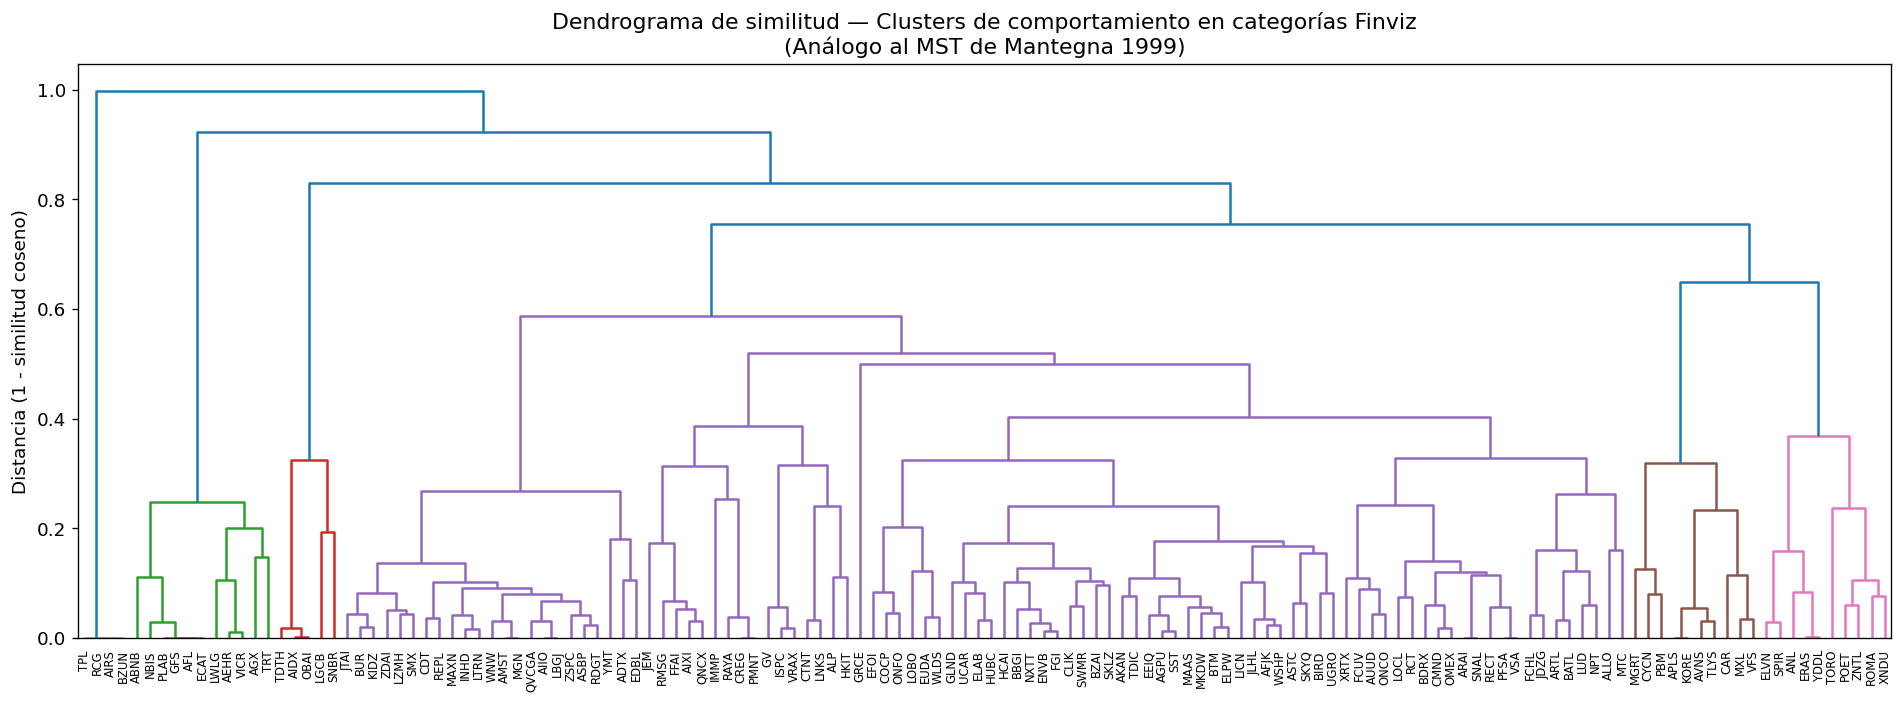

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

# Calcular matriz de distancia (1 - similitud de coseno)
from sklearn.metrics.pairwise import cosine_similarity

# Usar solo tickers con suficientes apariciones para clusters robustos
MIN_APPEARANCES = 5
ticker_robust = ticker_cat_filt[ticker_total >= MIN_APPEARANCES]
print(f'Tickers con >={MIN_APPEARANCES} apariciones para clustering: {len(ticker_robust)}')

sim = cosine_similarity(ticker_robust.values)
dist = 1 - sim
np.fill_diagonal(dist, 0)  # diagonal exactamente 0
dist = np.clip(dist, 0, None)  # evitar valores negativos por floating point

dist_condensed = squareform(dist)

# Linkage jerárquico (ward = mínima varianza intra-cluster)
Z = linkage(dist_condensed, method='average')

# Dendrograma
fig, ax = plt.subplots(figsize=(16, 6))
dn = dendrogram(Z, labels=ticker_robust.index.tolist(), 
                ax=ax, leaf_rotation=90, leaf_font_size=7,
                color_threshold=0.6*max(Z[:,2]))
ax.set_title('Dendrograma de similitud — Clusters de comportamiento en categorías Finviz\n(Análogo al MST de Mantegna 1999)')
ax.set_ylabel('Distancia (1 - similitud coseno)')
plt.tight_layout()
plt.show()

Distribución por cluster:
cluster
1     4
2    11
3     5
4    98
5    20


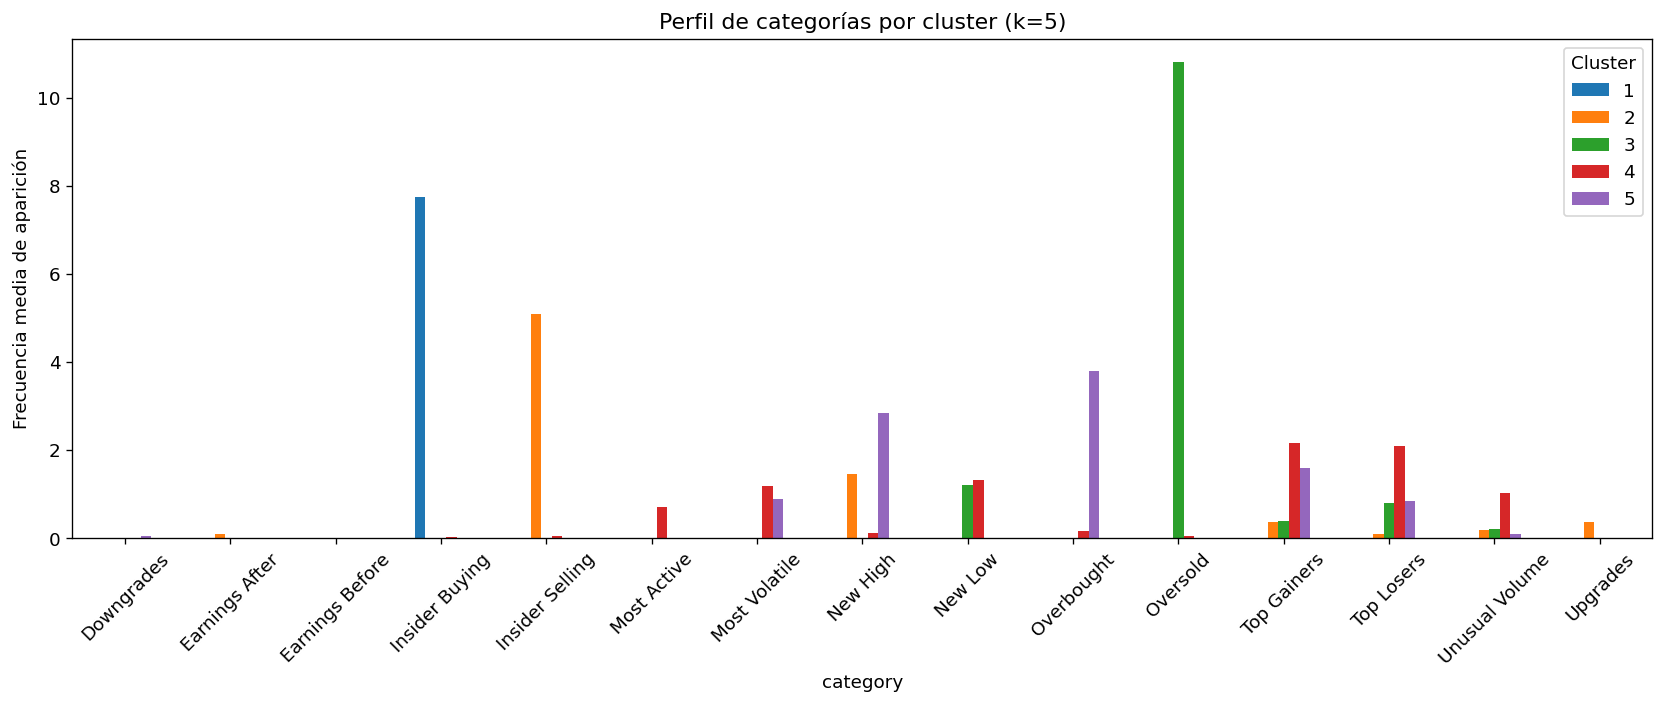

Cluster 1 (4 tickers): ['TPL', 'RCG', 'AIRS', 'BZUN']
Cluster 2 (11 tickers): ['AEHR', 'TRT', 'AGX', 'AFL', 'PLAB', 'ABNB', 'GFS', 'VICR']
Cluster 3 (5 tickers): ['AIDX', 'OBAI', 'TDTH', 'LGCB', 'SNBR']
Cluster 4 (98 tickers): ['CTNT', 'LNKS', 'FCHL', 'RDGT', 'AIXI', 'SKYQ', 'SST', 'HUBC']
Cluster 5 (20 tickers): ['MGRT', 'CAR', 'TLYS', 'PBM', 'AVNS', 'XNDU', 'KORE', 'MXL']


In [10]:
# Asignar clusters con corte en k=5 grupos
N_CLUSTERS = 5
cluster_labels = fcluster(Z, t=N_CLUSTERS, criterion='maxclust')
cluster_series = pd.Series(cluster_labels, index=ticker_robust.index, name='cluster')

print(f'Distribución por cluster:')
print(cluster_series.value_counts().sort_index().to_string())

# Perfil de cada cluster: qué categorías dominan
ticker_cat_with_cluster = ticker_robust.copy()
ticker_cat_with_cluster['cluster'] = cluster_labels

cluster_profile = ticker_cat_with_cluster.groupby('cluster').mean()

fig, ax = plt.subplots(figsize=(14, 6))
cluster_profile.T.plot(kind='bar', ax=ax)
ax.set_title(f'Perfil de categorías por cluster (k={N_CLUSTERS})')
ax.set_ylabel('Frecuencia media de aparición')
ax.legend(title='Cluster', bbox_to_anchor=(1,1))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Mostrar ejemplos de cada cluster
for c in range(1, N_CLUSTERS+1):
    members = cluster_series[cluster_series==c].index.tolist()
    # Ordenar por total de apariciones
    members_sorted = ticker_total[members].sort_values(ascending=False).index.tolist()
    print(f'Cluster {c} ({len(members)} tickers): {members_sorted[:8]}')

## 6. Trayectorias longitudinales — Evolución del ticker en la red

**Analogía:** El "expediente académico" del alumno. ¿Cómo ha evolucionado la posición del ticker a lo largo del trimestre?

Construimos una red por cada día/semana y medimos cómo cambia la centralidad de cada ticker. Un ticker que **gana centralidad** (empieza a aparecer en más categorías simultáneamente) puede ser una señal de actividad creciente.

In [11]:
# Construir matriz semanal de apariciones por categoría
df['week'] = df['date'].dt.to_period('W')
weeks = sorted(df['week'].unique())

# Score de actividad semanal: suma ponderada de apariciones
# Pesos conceptuales: categorías más "bullish" tienen más peso
CATEGORY_WEIGHTS = {
    'Top Gainers': 2.0,
    'New High': 2.0,
    'Unusual Volume': 1.5,
    'Overbought': 1.0,
    'Most Volatile': 0.5,
    'Most Active': 0.5,
    'Upgrades': 1.5,
    'Earnings Before': 0.5,
    'Earnings After': 0.5,
    'Insider Buying': 1.0,
    'Top Losers': -2.0,
    'New Low': -2.0,
    'Oversold': -1.0,
    'Downgrades': -1.5,
    'Insider Selling': -0.5,
}

df['cat_weight'] = df['category'].map(CATEGORY_WEIGHTS).fillna(0)

# Score semanal por ticker
weekly_score = df.groupby(['ticker','week'])['cat_weight'].sum().unstack(fill_value=0)
weekly_score.columns = [str(c) for c in weekly_score.columns]

# Filtrar tickers que aparecen al menos en 3 semanas
weeks_active = (weekly_score != 0).sum(axis=1)
weekly_score_filt = weekly_score[weeks_active >= 3]

print(f'Tickers con actividad en >=3 semanas: {len(weekly_score_filt)}')
print(f'Semanas disponibles: {weekly_score.shape[1]}')
weekly_score.head(3)

Tickers con actividad en >=3 semanas: 83
Semanas disponibles: 5


,2026-03-23/2026-03-29,2026-03-30/2026-04-05,2026-04-06/2026-04-12,2026-04-13/2026-04-19,2026-04-20/2026-04-26
ticker,,,,,
AA,0.0,0.0,1.5,0.0,0.0
AAOI,0.0,0.0,1.5,0.0,0.0
AAON,0.0,0.0,0.0,0.0,-0.5


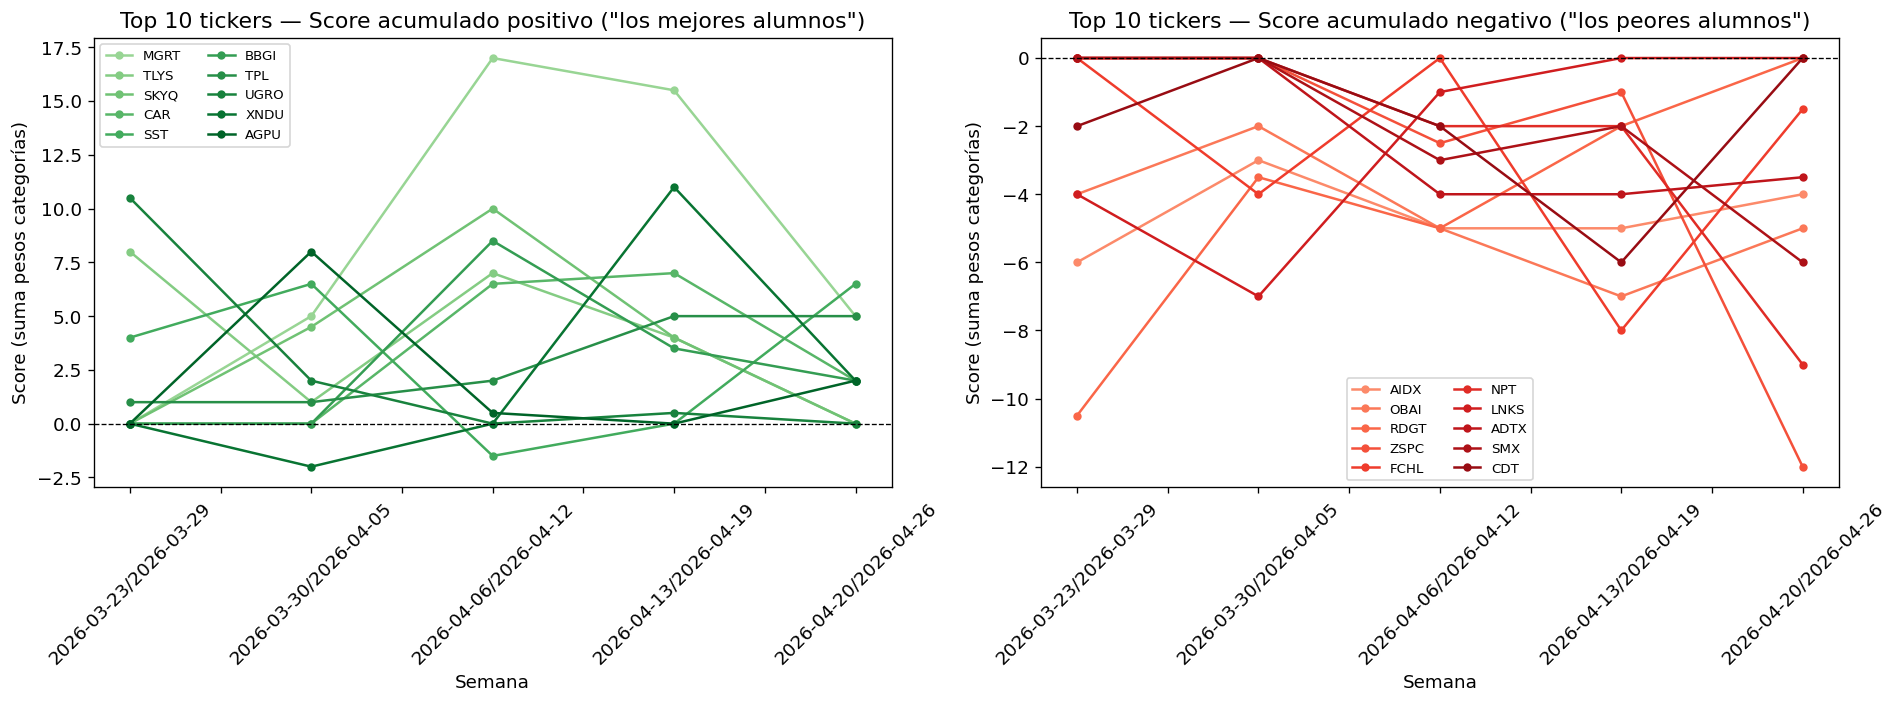

In [12]:
# Trayectorias: mostrar evolución de los 10 tickers con mayor score acumulado
total_score = weekly_score_filt.sum(axis=1)
top_bullish = total_score.nlargest(10).index.tolist()
top_bearish = total_score.nsmallest(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tickers, title, cmap_name in [
    (axes[0], top_bullish, 'Top 10 tickers — Score acumulado positivo ("los mejores alumnos")', 'Greens'),
    (axes[1], top_bearish, 'Top 10 tickers — Score acumulado negativo ("los peores alumnos")', 'Reds')
]:
    cmap = plt.colormaps[cmap_name]
    colors = cmap(np.linspace(0.4, 0.9, len(tickers)))
    for i, ticker in enumerate(tickers):
        weekly_score_filt.loc[ticker].plot(ax=ax, marker='o', markersize=4,
                                            label=ticker, color=colors[i])
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Semana')
    ax.set_ylabel('Score (suma pesos categorías)')
    ax.legend(fontsize=8, ncol=2)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

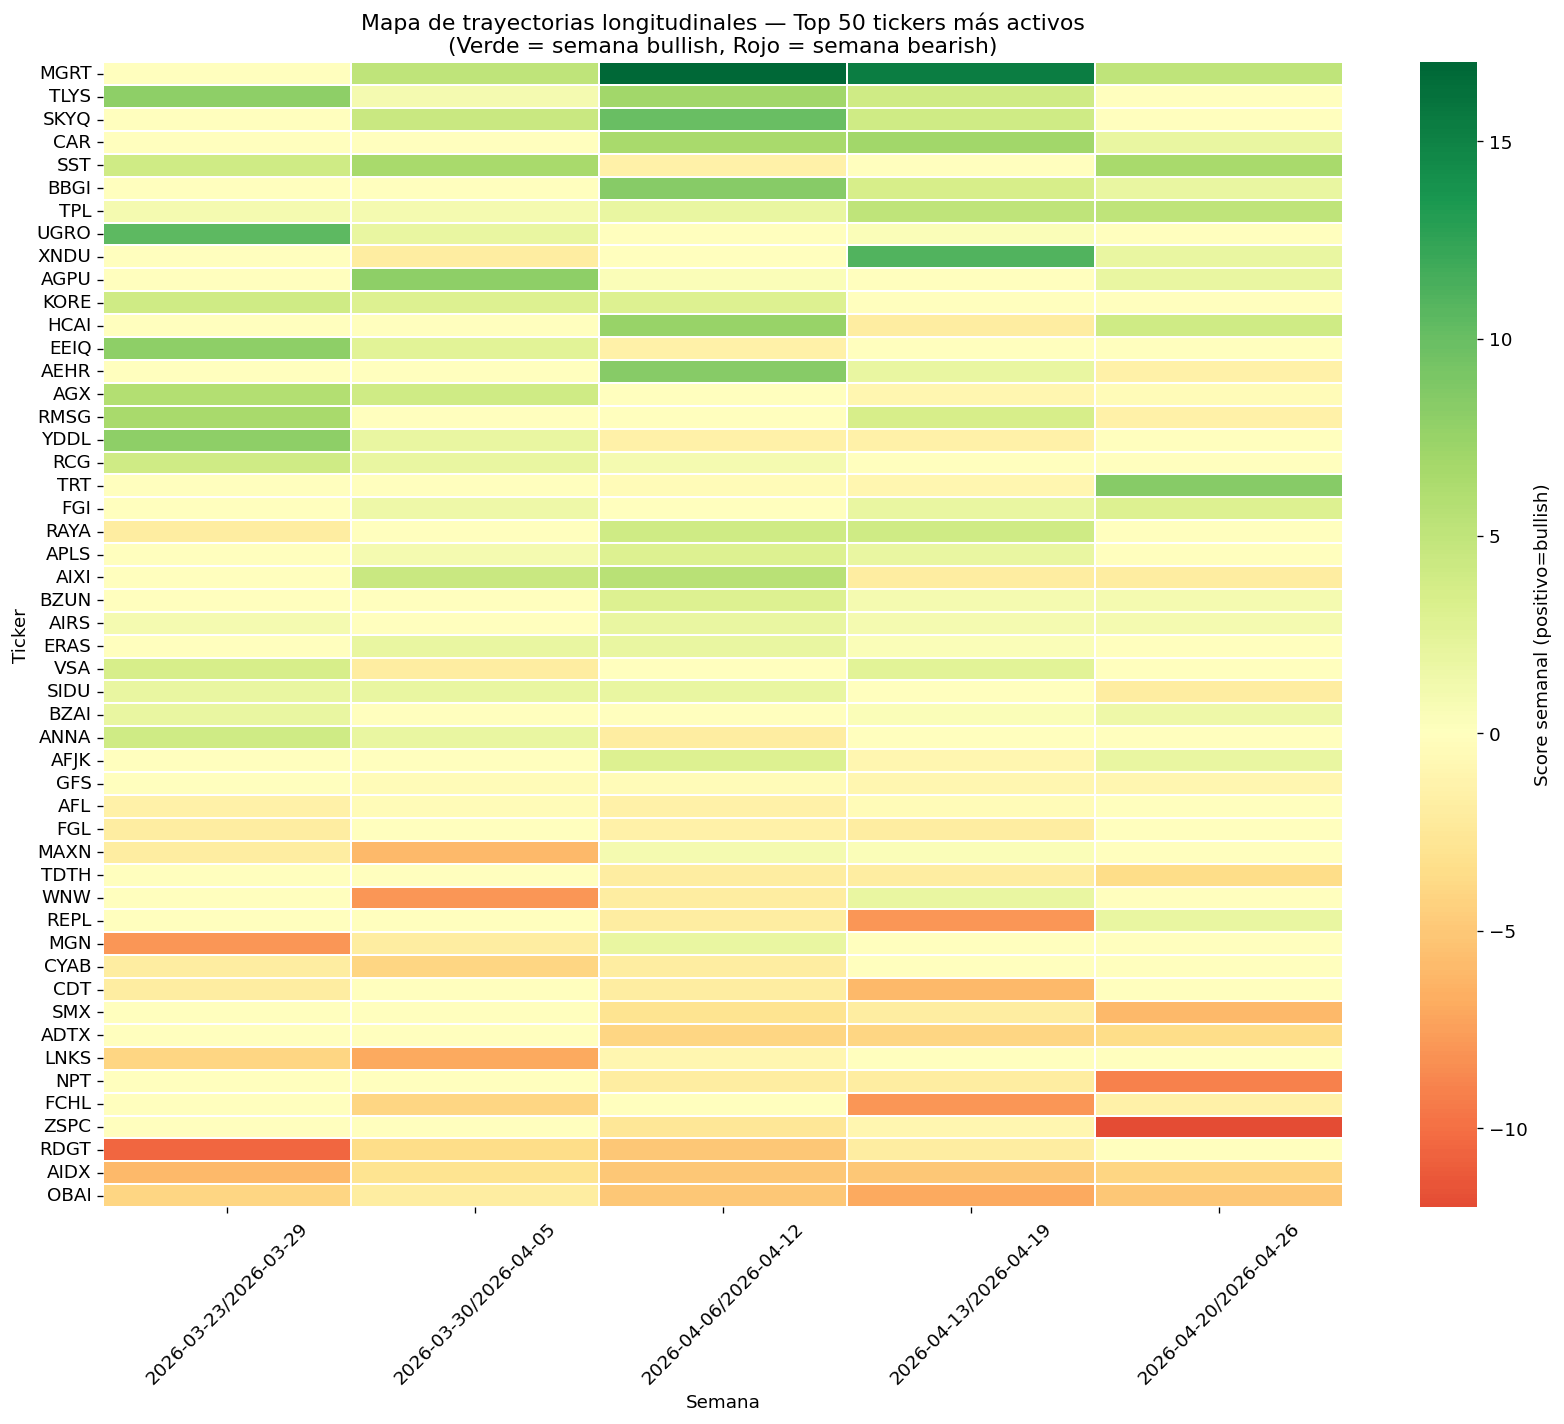

In [13]:
# Mapa de calor longitudinal: todos los tickers activos × semana
# Ordena por score total para que los "mejores" estén arriba

scores_sorted = weekly_score_filt.loc[total_score.abs().nlargest(50).index]
scores_sorted = scores_sorted.loc[total_score[scores_sorted.index].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(scores_sorted, cmap='RdYlGn', center=0, 
            ax=ax, linewidths=0.2, 
            cbar_kws={'label': 'Score semanal (positivo=bullish)'},
            yticklabels=True, xticklabels=True)
ax.set_title('Mapa de trayectorias longitudinales — Top 50 tickers más activos\n(Verde = semana bullish, Rojo = semana bearish)')
ax.set_xlabel('Semana')
ax.set_ylabel('Ticker')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Matriz de transición Markov entre categorías

**Concepto:** Si un ticker está en "Top Gainers" hoy, ¿en qué categoría tiende a estar mañana? Esto es una **cadena de Markov**: el estado futuro depende solo del estado presente.

**Limitación importante:** Un ticker puede estar en múltiples categorías el mismo día. Aquí modelamos la transición de la categoría "más relevante" (la de mayor peso) para simplificar. En la siguiente sección generalizamos al modelo predictivo completo.

**Referencia:** Esta es la base del análisis de secuencias de Snijders et al. (2010) — estimar probabilidades de transición condicionadas al estado actual.

Transiciones calculadas: 827


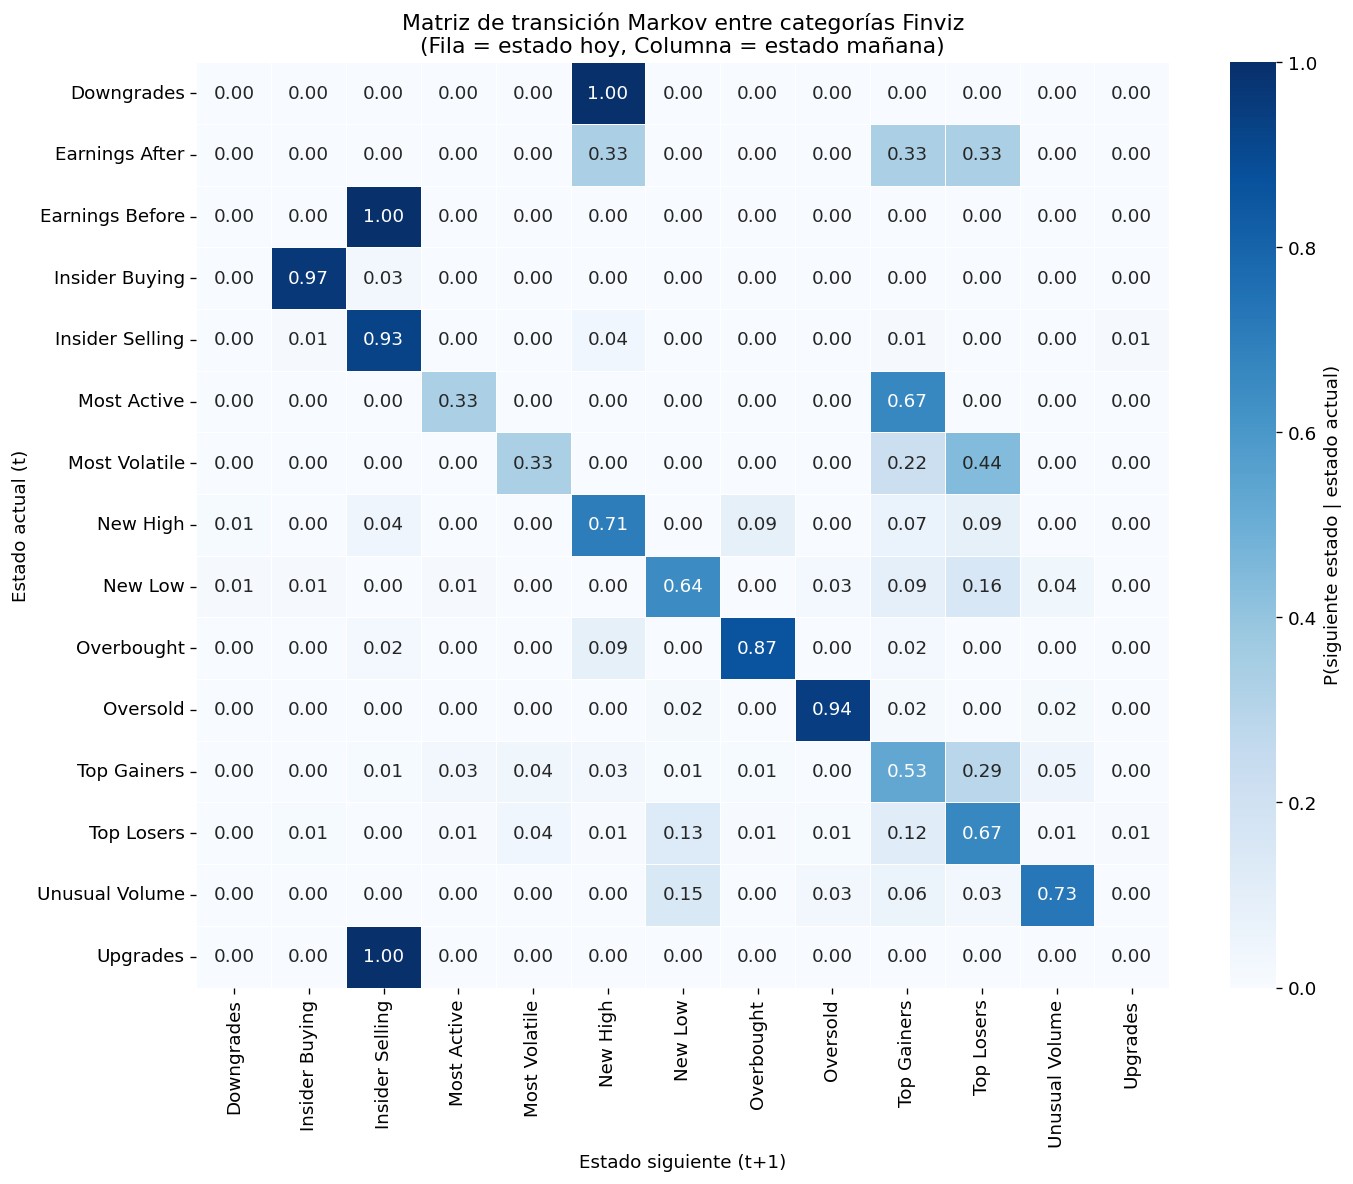


Interpretación: Lee la fila "Top Gainers" para ver a qué categoría tienden esos tickers al día siguiente.


In [14]:
# Asignar el estado primario de cada ticker cada día
# = categoría con mayor peso absoluto en ese día
df['abs_weight'] = df['cat_weight'].abs()
primary_state = df.sort_values('abs_weight', ascending=False).groupby(['ticker','date']).first().reset_index()
primary_state = primary_state[['ticker','date','category','cat_weight']].rename(columns={'category':'state'})
primary_state = primary_state.sort_values(['ticker','date'])

# Calcular transiciones día t → día t+1
transitions = []
for ticker, grp in primary_state.groupby('ticker'):
    grp = grp.sort_values('date')
    dates = grp['date'].tolist()
    states = grp['state'].tolist()
    for i in range(len(dates)-1):
        # Solo transiciones en días consecutivos (o separados por 1 fin de semana)
        delta = (dates[i+1] - dates[i]).days
        if delta <= 4:  # máximo 4 días (viernes → martes)
            transitions.append({'from': states[i], 'to': states[i+1]})

trans_df = pd.DataFrame(transitions)
print(f'Transiciones calculadas: {len(trans_df)}')

# Matriz de transición
trans_matrix = trans_df.groupby(['from','to']).size().unstack(fill_value=0)

# Normalizar por filas → probabilidades de transición
trans_prob = trans_matrix.div(trans_matrix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(trans_prob, cmap='Blues', ax=ax, annot=True, fmt='.2f',
            linewidths=0.3, cbar_kws={'label': 'P(siguiente estado | estado actual)'})
ax.set_title('Matriz de transición Markov entre categorías Finviz\n(Fila = estado hoy, Columna = estado mañana)')
ax.set_xlabel('Estado siguiente (t+1)')
ax.set_ylabel('Estado actual (t)')
plt.tight_layout()
plt.show()

print('\nInterpretación: Lee la fila "Top Gainers" para ver a qué categoría tienden esos tickers al día siguiente.')

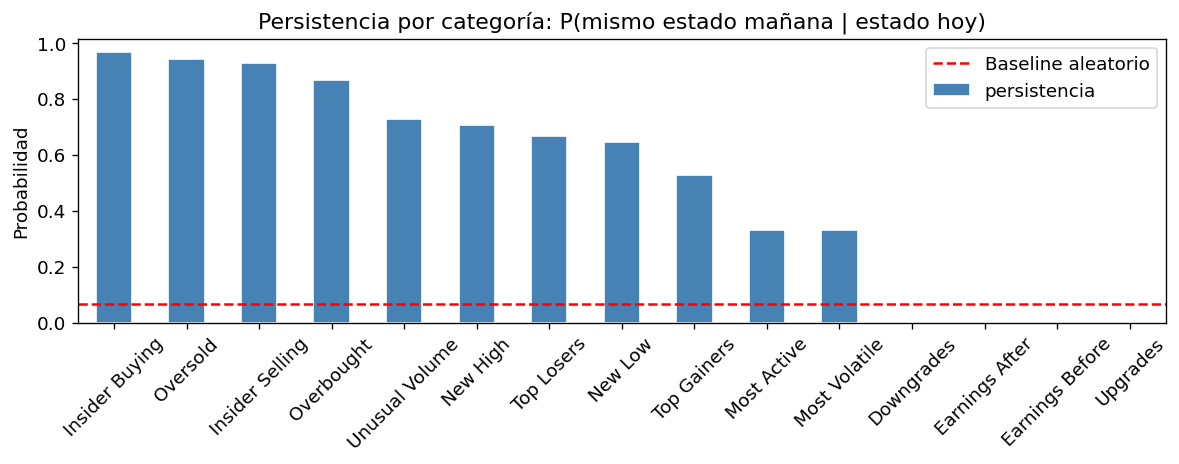


Categorías con persistencia > baseline son predecibles (el ticker tiende a repetir ese patrón).


In [15]:
# Insight clave: ¿Qué estado tiene mayor "persistencia" (probabilidad de quedarse en el mismo estado)?
persistence = pd.Series(
    {cat: trans_prob.loc[cat, cat] if cat in trans_prob.index and cat in trans_prob.columns else 0
     for cat in ALL_CATS},
    name='persistencia'
).sort_values(ascending=False).dropna()

fig, ax = plt.subplots(figsize=(10, 4))
persistence.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Persistencia por categoría: P(mismo estado mañana | estado hoy)')
ax.set_ylabel('Probabilidad')
ax.axhline(1/len(ALL_CATS), color='red', linestyle='--', label='Baseline aleatorio')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\nCategorías con persistencia > baseline son predecibles (el ticker tiende a repetir ese patrón).')

## 8. Señal predictiva: ¿La posición en la red predice el retorno siguiente?

**Pregunta central:** Si un ticker aparece en la categoría X hoy, ¿cuánto rinde mañana? Y si está en el cluster Y, ¿es mejor o peor predictor?

Usamos el `change_pct` del día como proxy de retorno intradía, y medimos el retorno del día siguiente para los tickers que aparecen en cada categoría.

In [16]:
# Construir tabla de retornos: para cada ticker con change_pct != 0, 
# calcular el retorno t+1 (si disponible)

# Primer paso: extraer el change_pct "mejor disponible" por ticker/día
# Priorizamos el dato con mayor información (change_pct != 0)
price_data = df[df['change_pct_num'] != 0].copy()

# Si un ticker aparece múltiples veces el mismo día con change_pct != 0,
# tomamos el valor de la categoría más representativa (mayor volumen)
price_data = price_data.sort_values('volume_num', ascending=False)
price_snap = price_data.drop_duplicates(subset=['ticker','date'], keep='first')[['ticker','date','change_pct_num','price_num','category']]
price_snap = price_snap.sort_values(['ticker','date'])

print(f'Filas con datos de precio (change_pct != 0): {len(price_snap)}')
print(f'Tickers únicos con precio: {price_snap["ticker"].nunique()}')

# Calcular retorno t+1: el change_pct del día siguiente para el mismo ticker
price_snap = price_snap.set_index(['ticker','date'])
price_snap['ret_t1'] = price_snap.groupby('ticker')['change_pct_num'].shift(-1)
price_snap = price_snap.reset_index()
price_snap_valid = price_snap.dropna(subset=['ret_t1'])

print(f'Pares con retorno t+1 disponible: {len(price_snap_valid)}')

Filas con datos de precio (change_pct != 0): 1606
Tickers únicos con precio: 916
Pares con retorno t+1 disponible: 690


In [17]:
# Retorno medio t+1 condicionado en la categoría de hoy
# Unir con las categorías del día t

# Expandir: un ticker puede tener múltiples categorías el mismo día
cat_by_day = df.groupby(['ticker','date'])['category'].apply(list).reset_index()
cat_by_day.columns = ['ticker','date','categories']

# Para el análisis predictivo, expandimos: una fila por categoría
cat_expanded = cat_by_day.explode('categories').rename(columns={'categories':'category'})

# Unir con retorno t+1
pred_df = cat_expanded.merge(price_snap_valid[['ticker','date','ret_t1']], on=['ticker','date'], how='inner')

print(f'Dataset predictivo: {len(pred_df)} observaciones')

# Retorno medio y mediano por categoría
cat_returns = pred_df.groupby('category')['ret_t1'].agg(['mean','median','std','count'])
cat_returns.columns = ['ret_mean', 'ret_median', 'ret_std', 'n']
cat_returns = cat_returns.sort_values('ret_mean', ascending=False)

print('\nRetorno t+1 por categoría (hoy en esta categoría → mañana):')
print(cat_returns.round(3).to_string())

Dataset predictivo: 1028 observaciones

Retorno t+1 por categoría (hoy en esta categoría → mañana):
                 ret_mean  ret_median  ret_std    n
category                                           
Unusual Volume     25.350     -14.200   84.605   64
Top Gainers        23.788       0.050   72.908  188
Most Active        20.528     -15.720  102.597   42
Downgrades         19.020      19.020      NaN    1
Most Volatile      17.388       3.390   48.987   90
Top Losers         17.153      -4.140   62.226  151
New Low            15.579      -7.820   55.180  103
Oversold           14.851       3.210   43.877   47
Overbought          9.007       1.595   28.823   74
New High            7.941       6.060   28.036   81
Upgrades            3.822       1.765    6.927    6
Insider Selling     2.722       0.875   10.519  136
Insider Buying      0.709       0.425    3.454   40
Earnings After     -1.520       0.330   26.563    3
Earnings Before   -10.160     -10.160   14.665    2


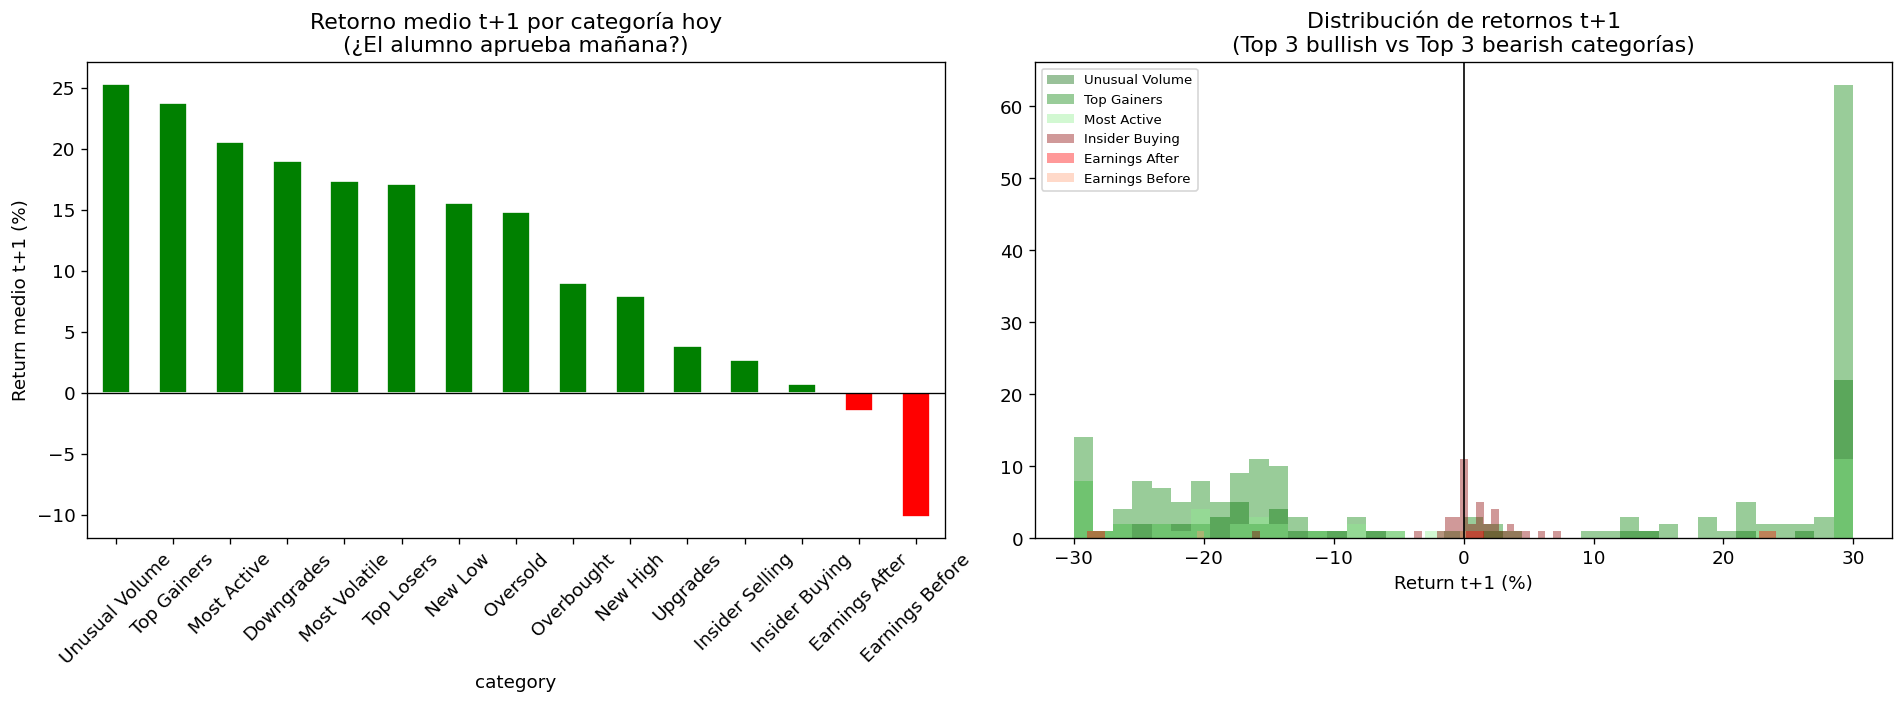

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Retorno medio t+1 por categoría
colors = ['green' if x > 0 else 'red' for x in cat_returns['ret_mean']]
cat_returns['ret_mean'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Retorno medio t+1 por categoría hoy\n(¿El alumno aprueba mañana?)')
axes[0].set_ylabel('Return medio t+1 (%)')
axes[0].tick_params(axis='x', rotation=45)

# Panel 2: Distribución de retornos para las 3 categorías más bullish vs bearish
top3 = cat_returns.head(3).index.tolist()
bot3 = cat_returns.tail(3).index.tolist()

for cat, color in zip(top3, ['darkgreen','green','lightgreen']):
    data = pred_df[pred_df['category']==cat]['ret_t1'].clip(-30, 30)
    axes[1].hist(data, bins=40, alpha=0.4, color=color, label=cat)

for cat, color in zip(bot3, ['darkred','red','lightsalmon']):
    data = pred_df[pred_df['category']==cat]['ret_t1'].clip(-30, 30)
    axes[1].hist(data, bins=40, alpha=0.4, color=color, label=cat)

axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Distribución de retornos t+1\n(Top 3 bullish vs Top 3 bearish categorías)')
axes[1].set_xlabel('Return t+1 (%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Dataset: 690 observaciones
Tasa de éxito base (aleatoria): 43.33%
Fold 1: AUC=0.555, Acc=0.512, Base rate=43.60%
Fold 2: AUC=0.616, Acc=0.599, Base rate=43.60%
Fold 3: AUC=0.543, Acc=0.558, Base rate=38.95%

Media AUC: 0.571


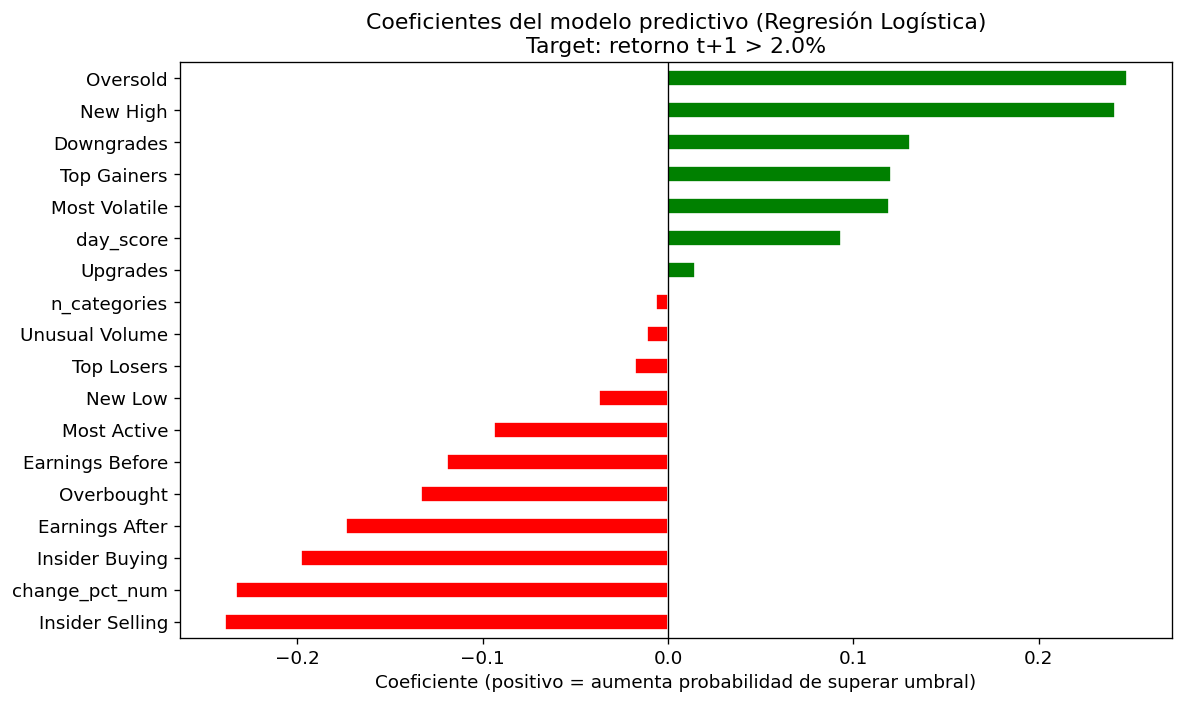

In [19]:
if not HAS_SK:
    print('scikit-learn no disponible.')
else:
    # ─── Modelo predictivo: Regresión Logística con features de red ───
    #
    # Variable dependiente: ¿el ticker sube >2% mañana? ("aprueba")
    # Predictores (features de red):
    #   - Presencia en cada categoría hoy (one-hot)
    #   - Número de categorías hoy (actividad total)
    #   - Score ponderado hoy
    #   - Retorno de hoy (momentum)
    
    THRESHOLD_WIN = 2.0  # % de subida para contar como "aprueba"
    
    # Construir features por ticker/día
    feat_pivot = df.groupby(['ticker','date','category']).size().unstack(fill_value=0).reset_index()
    feat_pivot.columns.name = None
    
    # Añadir score ponderado del día
    day_score = df.groupby(['ticker','date'])['cat_weight'].sum().reset_index().rename(columns={'cat_weight':'day_score'})
    feat_pivot = feat_pivot.merge(day_score, on=['ticker','date'], how='left')
    
    # Número de categorías
    n_cats_day = df.groupby(['ticker','date'])['category'].nunique().reset_index().rename(columns={'category':'n_categories'})
    feat_pivot = feat_pivot.merge(n_cats_day, on=['ticker','date'], how='left')
    
    # Añadir retorno de hoy y retorno t+1
    feat_pivot = feat_pivot.merge(price_snap_valid[['ticker','date','change_pct_num','ret_t1']], 
                                   on=['ticker','date'], how='inner')
    
    # Variable target
    feat_pivot['target'] = (feat_pivot['ret_t1'] > THRESHOLD_WIN).astype(int)
    
    print(f'Dataset: {len(feat_pivot)} observaciones')
    print(f'Tasa de éxito base (aleatoria): {feat_pivot["target"].mean():.2%}')
    
    # Features
    CAT_COLS = [c for c in ALL_CATS if c in feat_pivot.columns]
    FEATURE_COLS = CAT_COLS + ['day_score', 'n_categories', 'change_pct_num']
    
    X = feat_pivot[FEATURE_COLS].fillna(0)
    y = feat_pivot['target']
    dates_col = feat_pivot['date']
    
    # Validación temporal (TimeSeriesSplit) — CRÍTICO: no mezclar futuro con pasado
    tscv = TimeSeriesSplit(n_splits=3)
    
    # Ordenar por fecha
    sort_idx = dates_col.argsort().values
    X_sorted = X.values[sort_idx]
    y_sorted = y.values[sort_idx]
    
    results = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_sorted)):
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_sorted[train_idx])
        X_test = scaler.transform(X_sorted[test_idx])
        y_train = y_sorted[train_idx]
        y_test = y_sorted[test_idx]
        
        if y_train.sum() < 5 or y_test.sum() < 3:
            continue
        
        clf = LogisticRegression(max_iter=500, class_weight='balanced', C=0.1)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:,1]
        
        auc = roc_auc_score(y_test, y_prob)
        acc = (y_pred == y_test).mean()
        results.append({'fold': fold+1, 'n_train': len(y_train), 'n_test': len(y_test),
                        'auc': auc, 'accuracy': acc, 
                        'base_rate': y_test.mean()})
        print(f'Fold {fold+1}: AUC={auc:.3f}, Acc={acc:.3f}, Base rate={y_test.mean():.2%}')
    
    if results:
        results_df = pd.DataFrame(results)
        print(f'\nMedia AUC: {results_df["auc"].mean():.3f}')
        
        # Feature importance (último fold)
        coef_df = pd.Series(clf.coef_[0], index=FEATURE_COLS).sort_values()
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = ['green' if c > 0 else 'red' for c in coef_df.values]
        coef_df.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'Coeficientes del modelo predictivo (Regresión Logística)\nTarget: retorno t+1 > {THRESHOLD_WIN}%')
        ax.set_xlabel('Coeficiente (positivo = aumenta probabilidad de superar umbral)')
        plt.tight_layout()
        plt.show()

## 9. Conclusiones e hipótesis de trabajo

Esta sección es para anotar los hallazgos clave y las hipótesis que emergen del análisis.

In [20]:
# ─── Resumen ejecutivo automático ───

print('=' * 60)
print('RESUMEN EJECUTIVO — Análisis de Red Finviz')
print('=' * 60)
print(f'\nPERÍODO: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'UNIVERSO: {df["ticker"].nunique()} tickers únicos, {df["date"].nunique()} sesiones')

print('\n--- CATEGORÍAS MÁS PERSISTENTES (predecibles) ---')
for cat in persistence.head(5).index:
    p = persistence[cat]
    print(f'  {cat}: P(repetir mañana) = {p:.2%}')

print('\n--- SEÑAL PREDICTIVA POR CATEGORÍA (retorno t+1 medio) ---')
print(cat_returns[['ret_mean','n']].round(2).to_string())

print('\n--- HIPÓTESIS DE TRABAJO ---')
print("""
H1: Los tickers con alta centralidad de eigenvector tienen mayor correlación
    con el régimen de mercado. Son los "alumnos influenciados por la clase".

H2: La transición de una categoría de bajo score (Unusual Volume) a una de
    alto score (Top Gainers) en 1-2 días es una señal de momentum naciente.

H3: Los clusters identificados tienen perfiles de riesgo distintos:
    - Cluster alta persistencia en Top Gainers = momentum puro
    - Cluster alta persistencia en Unusual Volume = pre-momentum
    - Cluster con New High + Upgrades = breakout institucional

H4: Un ticker que aparece en >=3 categorías simultáneamente tiene mayor
    probabilidad de movimiento significativo al día siguiente (aunque
    la dirección depende de la combinación de categorías).

LIMITACIÓN CRÍTICA: Solo 22 días de datos → tamaño muestral pequeño para
conclusiones robustas. El modelo predictivo tiene alta varianza. Los resultados
son hipótesis a validar con más datos, no señales operativas.
""")

RESUMEN EJECUTIVO — Análisis de Red Finviz

PERÍODO: 2026-03-24 → 2026-04-24
UNIVERSO: 968 tickers únicos, 22 sesiones

--- CATEGORÍAS MÁS PERSISTENTES (predecibles) ---
  Insider Buying: P(repetir mañana) = 96.77%
  Oversold: P(repetir mañana) = 94.34%
  Insider Selling: P(repetir mañana) = 92.94%
  Overbought: P(repetir mañana) = 86.67%
  Unusual Volume: P(repetir mañana) = 72.73%

--- SEÑAL PREDICTIVA POR CATEGORÍA (retorno t+1 medio) ---
                 ret_mean    n
category                      
Unusual Volume      25.35   64
Top Gainers         23.79  188
Most Active         20.53   42
Downgrades          19.02    1
Most Volatile       17.39   90
Top Losers          17.15  151
New Low             15.58  103
Oversold            14.85   47
Overbought           9.01   74
New High             7.94   81
Upgrades             3.82    6
Insider Selling      2.72  136
Insider Buying       0.71   40
Earnings After      -1.52    3
Earnings Before    -10.16    2

--- HIPÓTESIS DE TRABAJO -

---

## Referencias académicas clave

1. **Mantegna (1999)** — *Hierarchical structure in financial markets*. European Physical Journal B. → Base del MST y la idea de que la estructura de correlaciones revela la organización interna del mercado.

2. **Peralta & Zareei (2016)** — *A network approach to portfolio selection*. Journal of Empirical Finance. → Demuestra que centralidad de red predice comportamiento futuro de activos.

3. **Billio et al. (2012)** — *Econometric measures of connectedness and systemic risk*. Journal of Financial Economics. → Redes de causalidad de Granger para predecir riesgo sistémico.

4. **Snijders et al. (2010)** — *Introduction to stochastic actor-based models for network dynamics*. Social Networks. → Modelar co-evolución de la red y el comportamiento de los actores.

5. **Blondel et al. (2008)** — *Fast unfolding of communities in large networks*. Journal of Statistical Mechanics. → Algoritmo Louvain para detección de comunidades.

---
*Notebook creado el 2026-04-24. Datos: Finviz Snapshots DB (22 sesiones, 24 Mar – 24 Abr 2026).*